In [339]:
import pandas as pd
import numpy as np
from biom import load_table

## Merge data layers 

In [340]:
# Load fecal and plasma metadata

md_fecal = pd.read_csv('/home/lakhatib/ADRC/data/metadata/adrc_metadata.tsv', sep = '\t', dtype=str)

md_plasma = pd.read_csv('/home/lakhatib/ADRC_plasma/data/ADRC_NACCSubsetUDS_ADI_NO_NATIVE_AMER_for_654_Plasma_2024-10-24.csv', dtype={'Kit.Number': str}).set_index('Kit.Number')

In [341]:
print(md_fecal.shape)
print(md_plasma.shape)

(1312, 352)
(638, 302)


In [342]:
# Load data with all platforms combined

plasma = pd.read_csv('/home/lakhatib/ADRC_plasma/data/1-Plasma platforms combined_v3_2025-07-15.csv', dtype=str)

In [343]:
# Next, for multiple samples from one participant, we will keep the plasma samples that were closest to fecal sample dates
plasma = plasma.dropna(subset='Fecal.plasma.days.diff')
plasma['Fecal.plasma.days.diff'] = plasma['Fecal.plasma.days.diff'].astype(int)

# Group by subject ID, and choose smallest number of days from fecal to plasma sample collection 
plasma = plasma.loc[plasma.groupby('NACC.ID')['Fecal.plasma.days.diff'].idxmin()]

In [344]:

# Set index to match fecal and plasma samples by kit number
plasma = plasma.set_index('fecal_kit')
md_fecal = md_fecal.set_index('Kit.Number')

In [345]:
# Drop any samples in fecal metadata that aren't present in plasma data and vice versa
md_fecal = md_fecal.loc[md_fecal.index.intersection(plasma.index)]
plasma = plasma.loc[plasma.index.intersection(md_fecal.index)]

In [346]:
# Add sample name column to plasma data to match with feature table
plasma['sample_name'] = md_fecal['sample_name']

In [347]:
# set index back to plasma kit number to match with plasma metadata, and add sample name to match feature table
plasma = plasma.set_index('Kit.Number Plasma', drop=False)
md_plasma = md_plasma.loc[md_plasma.index.intersection(plasma.index)]
md_plasma['sample_name'] = plasma['sample_name']


In [348]:
# Set sample_name as index across both metadatas and plasma data
md_plasma = md_plasma.set_index('sample_name')
md_fecal = md_fecal.set_index('sample_name', drop=False)
plasma = plasma.set_index('sample_name', drop=False)

In [349]:
# Import featuretable
ft = load_table('../../data/micov_filtered_feature-table.biom')

In [350]:
# Filter to samples present in plasma metadata and plasma data
ft = ft.filter(md_plasma.index, axis='sample')
plasma = plasma.loc[plasma.index.intersection(ft.ids(axis='sample'))]

In [351]:
ft.to_dataframe().T.index.duplicated().sum()

0

In [352]:
# Save matched data 
plasma.to_csv('../data/all_plasma_data_matched.csv')

## Clean metadata

In [353]:
# Save new column as binary CU/CI
md_plasma['Diagonsis'] = md_plasma['NACCUDSD'].replace({1: 'Cognitively Unimpaired', 2: 'Cognitively Impaired', 3: 'Cognitively Impaired', 4: 'Cognitively Impaired'})

In [354]:
# Replace missing values as np.nan
md_plasma['MOCA'] = md_plasma['NACCMOCA'].replace({-4.0: np.nan, 88.0: np.nan})
md_plasma['Antidepressants'] = md_plasma['NACCADEP'].replace({-4.0: np.nan})

md_plasma['UDSBENTD'] = np.where((md_plasma['UDSBENTD'] < 0) | (md_plasma['UDSBENTD'] > 17), np.nan, md_plasma['UDSBENTD'])
md_plasma['CRAFTDRE'] = np.where((md_plasma['CRAFTDRE'] < 0) | (md_plasma['CRAFTDRE'] > 25), np.nan, md_plasma['CRAFTDRE'])

In [355]:
# Remove duplicated samples
md_plasma = md_plasma[~md_plasma.index.duplicated()]

In [356]:
md_plasma = md_plasma[md_plasma['NACCAGE'] != 25]

In [357]:
md_plasma['NACCBMI'].sort_values()

sample_name
15448.0005792739     -4.0
15448.42617362       -4.0
15448.42202982       -4.0
15448.0005919356     -4.0
15448.0042233391     -4.0
                    ...  
15448.42517621      888.8
15448.5823422       888.8
15448.0042310488    888.8
15448.42319834      888.8
15448.42368322      888.8
Name: NACCBMI, Length: 506, dtype: float64

In [358]:
md_plasma['NACCBMI'] = md_plasma['NACCBMI'].replace({-4.0: np.nan, 88.0: np.nan, 888.8: np.nan})

In [359]:
md_plasma['HD-X pTau217'].value_counts()

0.23    2
0.15    2
0.21    2
0.30    2
0.26    2
0.36    1
0.67    1
0.92    1
0.13    1
0.57    1
0.10    1
0.60    1
0.62    1
0.48    1
0.78    1
0.34    1
0.17    1
0.66    1
0.52    1
0.32    1
0.45    1
0.85    1
0.16    1
0.35    1
2.54    1
0.31    1
Name: HD-X pTau217, dtype: int64

In [360]:
md_plasma['AMYLPET'] = md_plasma['AMYLPET'].replace({-4.0: np.nan, 8.0: np.nan})

In [361]:
md_plasma['AMYLCSF'] = md_plasma['AMYLCSF'].replace({-4.0: np.nan, 8.0: np.nan})

In [362]:
md_plasma['HIPPATR'] = md_plasma['HIPPATR'].replace({-4.0: np.nan, 8.0: np.nan})

In [363]:
md_plasma['TAUPETAD'] = md_plasma['TAUPETAD'].replace({-4.0: np.nan, 8.0: np.nan})

In [364]:
md_plasma['CSFTAU'] = md_plasma['CSFTAU'].replace({-4.0: np.nan, 8.0: np.nan})

In [365]:
md_plasma['CSFTAU'].value_counts()

0.0    27
1.0     9
Name: CSFTAU, dtype: int64

In [366]:
# Rename columns
md_plasma = md_plasma.rename(columns={'DEP':'Depression', 'AMYLPET': 'Amyloid PET', 'AMYLCSF': 'Amyloid CSF', 'HIPPATR': 'Hippocampal Atrophy',
                                      'ANXIET': 'Anxiety', 'HD-X pTau181': 'pTau181', 'HD-X pTau217': 'pTau217', 'TAUPETAD': 'Tau PET','CSFTAU': 'Tau CSF',
                                     'HD-X NFL': 'NFL', 'HD-X GFAP': 'GFAP', 'Lumipulse ABeta40': 'Abeta40', 'Lumipulse ABeta42': 'Abeta42',
                                     'Most Likely Fasting[based on 4 platforms]': 'fasting'})

In [367]:
# Merge ADI information
adi = pd.read_csv('/home/lakhatib/ADRC/data/ADI_2022_PLASMA_NO_PHI_NO_NATIVE_AMER_2025-01-10_1439.csv')
adi = adi.rename(columns={'NACCID': 'NACC.ID'})
md_plasma = md_plasma.reset_index()
md_plasma = pd.merge(md_plasma, adi[['NACC.ID', 'ADI_NAT', 'ADI_STATE', 'site']], on='NACC.ID', how='left').set_index('sample_name')
md_plasma = md_plasma.rename(columns={'NACCID': 'NACC.ID', 'ADI_NAT_y': 'ADI_NAT', 'ADI_STATE_y': 'ADI_STATE'})

In [368]:
# Merge diet information

diet = pd.read_csv('/home/lakhatib/ADRC/data/metadata/diet_data_clean.csv', dtype={'sample_name': str}).set_index('sample_name')
diet = diet[~diet.index.duplicated()]
hei = diet.filter(like='HEI2015')
md_plasma = pd.merge(md_plasma, hei, how='left', right_index=True, left_index=True)

In [374]:
md_plasma['fiber'] = diet['fiber']

In [375]:
# Define outcomes 
outcomes = ['Diagonsis', 'fiber', 'Amyloid PET', 'CRAFTDRE','Amyloid CSF', 'Hippocampal Atrophy', 'Tau PET', 'Tau CSF', 'MOCA', 'UDSBENTD', 'Depression', 'Anxiety', 'Antidepressants', 'pTau181', 'pTau217', 'NFL', 'GFAP', 
            'Abeta40', 'Abeta42', 'ADI_NAT', 'ADI_STATE', 'site', 'NACCAGE', 'SEX', 'NACCBMI', 'fasting'] + list(md_plasma.filter(like='HEI2015').columns)

In [376]:
md_plasma['Antidepressants'].value_counts()

0.0    359
1.0    144
Name: Antidepressants, dtype: int64

In [377]:
# Save metadatas

md_plasma.to_csv('../data/plasma_metadata_matched_all_outcomes.tsv', sep = '\t')
md_plasma_outcomes = md_plasma[outcomes]
md_plasma_outcomes.to_csv('../data/plasma_metadata_matched_main_outcomes.tsv', sep = '\t')

In [378]:
ft = ft.filter(ids_to_keep=md_plasma.index, axis='sample')

In [379]:
# save matched feature table
with open("../data/micov_filtered_feature-table_matched.biom", "w") as f:
    f.write(ft.to_json("Generated by script"))

## Clean Fecal Metabolomics/Foodomics

In [286]:
foodomics = pd.read_csv('/home/lakhatib/ADRC_plasma/data/Molecule Transition Results_ADRC_FecalsetOne.csv')

In [287]:
set1 = pd.read_csv('/home/lakhatib/ADRC/data/metabolomics/20240502_U19_ADRC_Set1_main_iimn_quant.csv')

In [288]:
md = pd.read_csv('/home/lakhatib/ADRC/data/metadata/adrc_metadata.tsv', sep = '\t', dtype=str)

In [289]:
md = md.set_index('Specimen.Bar.Code')

In [290]:
num = split.apply(lambda x: x[-1])

In [291]:
foodomics.index = num

In [292]:
foodomics = foodomics.loc[foodomics.index.intersection(md.index)]

In [293]:
foodomics['sample_name'] = md['sample_name']

In [294]:
foodomics = foodomics.set_index('sample_name')

In [295]:
foodomics = foodomics.pivot_table(
    index='sample_name',
    columns='Molecule',
    values='Area_sub',
    # aggfunc='first'  # or 'mean' if duplicates exist
)

In [296]:
foodomics.to_csv('../data/foodomics_adrc_fecal_set_one.csv')

## Annotate and clean plasma data layers

In [297]:
# Load annotation file
annotations = pd.read_excel('/home/lakhatib/ADRC_plasma/data/plasma_tables_by_platform/Variables and platforms.xlsx')

In [298]:
# Keep metabolites present in plasma data

cols = {}

for platform in annotations['Platform'].unique():
    cols[platform] = []
    for metabolite in annotations[annotations['Platform'] == platform]['Variable']:
        if metabolite in plasma.columns:
            cols[platform].append(metabolite)
    else:
        print(f"{metabolite} from {platform} not in plasma dataframe")

S_HDL_TG_pct from Nightingale not in plasma dataframe
PC.38.6....OH. from Baker not in plasma dataframe
X.26220 from Metabolon not in plasma dataframe
Citric.acid from Wishart Biocrates not in plasma dataframe
Vitamin.B9 from Wishart Water soluble vitamines not in plasma dataframe
beta.gamma.Tocopherol from Wishart Fat soluble vitamines not in plasma dataframe
Strontium from Wishart Metals not in plasma dataframe
xylose from WCMC Known not in plasma dataframe
yy_99.0457_28.53 of Untitled 10 from WCMC Unknown not in plasma dataframe
Vitamin E acetate 3 from UCSD Known not in plasma dataframe
X999 from UCSD unknown not in plasma dataframe
1-(4-methoxyphenyl)-1H-pyrrole from WCMC (FIEHN) not in plasma dataframe
Valine from Tuulia Known not in plasma dataframe
Unknown_metabolite 641 from Tuulia unknown not in plasma dataframe


In [299]:
# Create separate feature tables per platform
dfs = {}

for platform in annotations['Platform'].unique():
    dfs[platform] = plasma[cols[platform]]

In [300]:
# Count number of metabolites per platform

for platform in annotations['Platform'].unique():
    dfs[platform] = dfs[platform].loc[dfs[platform].index.intersection(md_plasma.index)]
    print(f'{platform} {dfs[platform].shape}')

Nightingale (506, 242)
Baker (506, 820)
Metabolon (506, 1059)
Wishart Biocrates (506, 554)
Wishart Water soluble vitamines (506, 7)
Wishart Fat soluble vitamines (506, 5)
Wishart Metals (506, 11)
WCMC Known (506, 534)
WCMC Unknown (506, 2553)
UCSD Known (506, 403)
UCSD unknown (506, 7309)
WCMC (FIEHN) (506, 116)
Tuulia Known (506, 126)
Tuulia unknown (506, 608)


In [301]:
pd.read_csv('/home/lakhatib/ADRC/data/metabolomics/20240502_U19_ADRC_Set1_main_iimn_quant.csv')

,row ID,row m/z,row retention time,row ion mobility,row ion mobility unit,row CCS,correlation group ID,annotation network number,best ion,auto MS2 verify,...,P7_H1_42230443.mzML Peak area,P7_H11_42309581.mzML Peak area,P7_H8_42304912.mzML Peak area,P7_H9_42297559.mzML Peak area,P7_H5_42301512.mzML Peak area,P7_H6_42291188.mzML Peak area,P7_H2_42213334.mzML Peak area,P7_H7_42116428.mzML Peak area,P7_H4_42300766.mzML Peak area,Unnamed: 729
0,4326,100.075754,0.547097,NaN,NaN,NaN,894.0,NaN,NaN,NaN,...,3.520367e+04,1.732747e+04,1.070558e+04,1.936551e+04,1.433717e+04,3.264857e+03,3.606665e+04,1.436152e+04,2.751752e+04,NaN
1,6697,100.075757,1.065544,NaN,NaN,NaN,460.0,NaN,NaN,NaN,...,4.110126e+03,2.289478e+03,1.165025e+03,1.184138e+03,3.477418e+02,5.919198e+02,3.680551e+03,2.057631e+02,1.837520e+03,NaN
2,954,101.059818,0.222268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.593907e+03,2.268790e+04,5.153580e+03,3.782070e+01,0.000000e+00,4.324595e+01,3.796675e+01,4.090879e+02,9.811518e+03,NaN
3,54780,101.071035,8.111314,NaN,NaN,NaN,668.0,2090.0,[M+NH4]+,NaN,...,1.206511e+07,1.220123e+07,1.361415e+07,9.879833e+06,1.212431e+07,1.162789e+07,1.214498e+07,1.430864e+07,1.257603e+07,NaN
4,51118,101.071049,7.192847,NaN,NaN,NaN,412.0,NaN,NaN,NaN,...,1.208617e+06,4.150572e+05,4.516473e+05,1.386094e+06,3.868196e+05,3.475139e+05,1.700530e+06,4.581504e+05,9.423578e+05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20623,46905,1324.106951,6.401384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
20624,52191,1342.930357,7.445152,NaN,NaN,NaN,35.0,1894.0,[2M+NH4]+,NaN,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
20625,51658,1343.932396,7.412755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
20626,46038,1386.635019,6.183139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN


In [302]:
# Save separated feature tables
for df in dfs.keys():
    dfs[df].to_csv(f'../data/{df}.csv')

In [303]:
# Merge different Wishart datasets and save
wishart = pd.merge(dfs['Wishart Biocrates'], dfs['Wishart Water soluble vitamines'], left_index=True, right_index=True)
wishart = pd.merge(wishart, dfs['Wishart Fat soluble vitamines'], left_index=True, right_index=True)
wishart = pd.merge(wishart, dfs['Wishart Metals'], left_index=True, right_index=True)
wishart.to_csv('../data/wishart_combined.csv')

In [304]:
# Combine and save Fiehn
fiehn = pd.merge(dfs['WCMC (FIEHN)'], dfs['WCMC Known'], left_index=True, right_index=True)
fiehn = pd.merge(fiehn, dfs['WCMC Unknown'], left_index=True, right_index=True)
fiehn.to_csv('../data/fiehn_combined.csv')

In [305]:
# Combine and save UCSD
ucsd = pd.merge(dfs['UCSD Known'], dfs['UCSD unknown'], left_index=True, right_index=True)
ucsd.to_csv('../data/ucsd_combined.csv')

In [306]:
# Combine and save tuulia
tuulia = pd.merge(dfs['Tuulia Known'], dfs['Tuulia unknown'], left_index=True, right_index=True)
tuulia.to_csv('../data/tuulia_combined.csv')

In [307]:
# define new feature tables for upset plot
dfs = {
    'Nightingale': dfs['Nightingale'],
    'Baker': dfs['Baker'],
    'Metabolon': dfs['Metabolon'],
    # 'Wishart' : wishart,
    # 'Fiehn' : fiehn,
    'UCSD' : ucsd,
    # 'Tuulia' : tuulia,
    'Metagenomics': ft.to_dataframe().T
}

In [308]:
dfs_no_nans = {}

for df in dfs:
    print(df)
    dfs_no_nans[df] = dfs[df].dropna(how='all')
    print(dfs_no_nans[df].shape)

Nightingale
(485, 242)
Baker
(504, 820)
Metabolon
(505, 1059)
UCSD
(495, 7712)
Metagenomics
(506, 2709)


/tmp/ipykernel_80608/2897009264.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

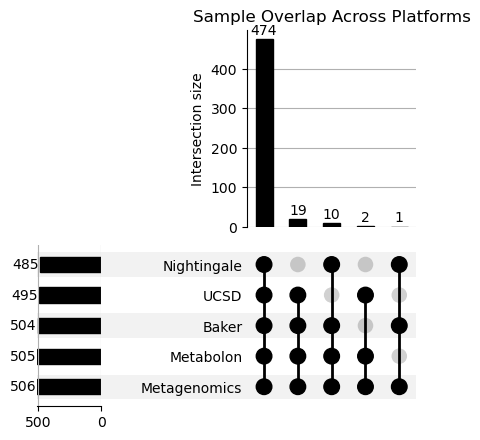

In [309]:
# Step 1: Get all unique sample names across all datasets
all_samples = set().union(*[set(df.index) for df in dfs_no_nans.values()])

# Step 2: Create a binary matrix: rows = samples, cols = platforms
sample_matrix = pd.DataFrame(
    {platform: [sample in df.index for sample in all_samples] for platform, df in dfs_no_nans.items()},
    index=sorted(all_samples)
)


from upsetplot import from_indicators, UpSet
import matplotlib.pyplot as plt

# Convert binary matrix to UpSet format
data = from_indicators(sample_matrix, data=None)

# Plot
plt.figure(figsize=(12, 6))
UpSet(data, subset_size='count', show_counts=True, sort_by='cardinality').plot()
plt.title('Sample Overlap Across Platforms')
plt.tight_layout()
plt.savefig('../figures/sample_size_upset_plot.png', bbox_inches='tight')
plt.show()


In [310]:
filtered_df = sample_matrix[sample_matrix.all(axis=1)]

In [311]:
md_plasma = md_plasma.loc[filtered_df.index]

In [312]:
# Save metadatas

md_plasma.to_csv('../data/plasma_metadata_matched_four_platforms.tsv', sep = '\t')